## Install package

In [1]:
!pip install -qU langchain langchain-openai langfuse

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.2/479.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.8 MB/s eta 0:00:00


## Add credentials

In [2]:
import os
from google.colab import userdata

# Configuration constants
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')  # Your OpenAI API key
os.environ["LANGFUSE_PUBLIC_KEY"] = userdata.get('LANGFUSE_PUBLIC_KEY')  # Get from Langfuse project settings
os.environ["LANGFUSE_SECRET_KEY"] = userdata.get('LANGFUSE_SECRET_KEY')  # Get from Langfuse project settings
os.environ['LANGFUSE_HOST'] = "https://cloud.langfuse.com"  # Langfuse cloud host

## Getting Started

### Instrument your application

In [3]:
from langfuse import get_client
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
langfuse = get_client()

# Create a span using a context manager
with langfuse.start_as_current_observation(as_type="span", name="process-request") as span:
    # Your processing logic here
    span.update(output="Processing complete")

    # Create a nested generation for an LLM call
    with langfuse.start_as_current_observation(as_type="generation", name="llm-response", model="gpt-4o-mini") as generation:
        # Your LLM call logic here
        llm.invoke("Hello, world!")
        generation.update(output="Generated response")

# All spans are automatically closed when exiting their context blocks


# Flush events in short-lived applications
langfuse.flush()

### Run your application and see the trace in Langfuse

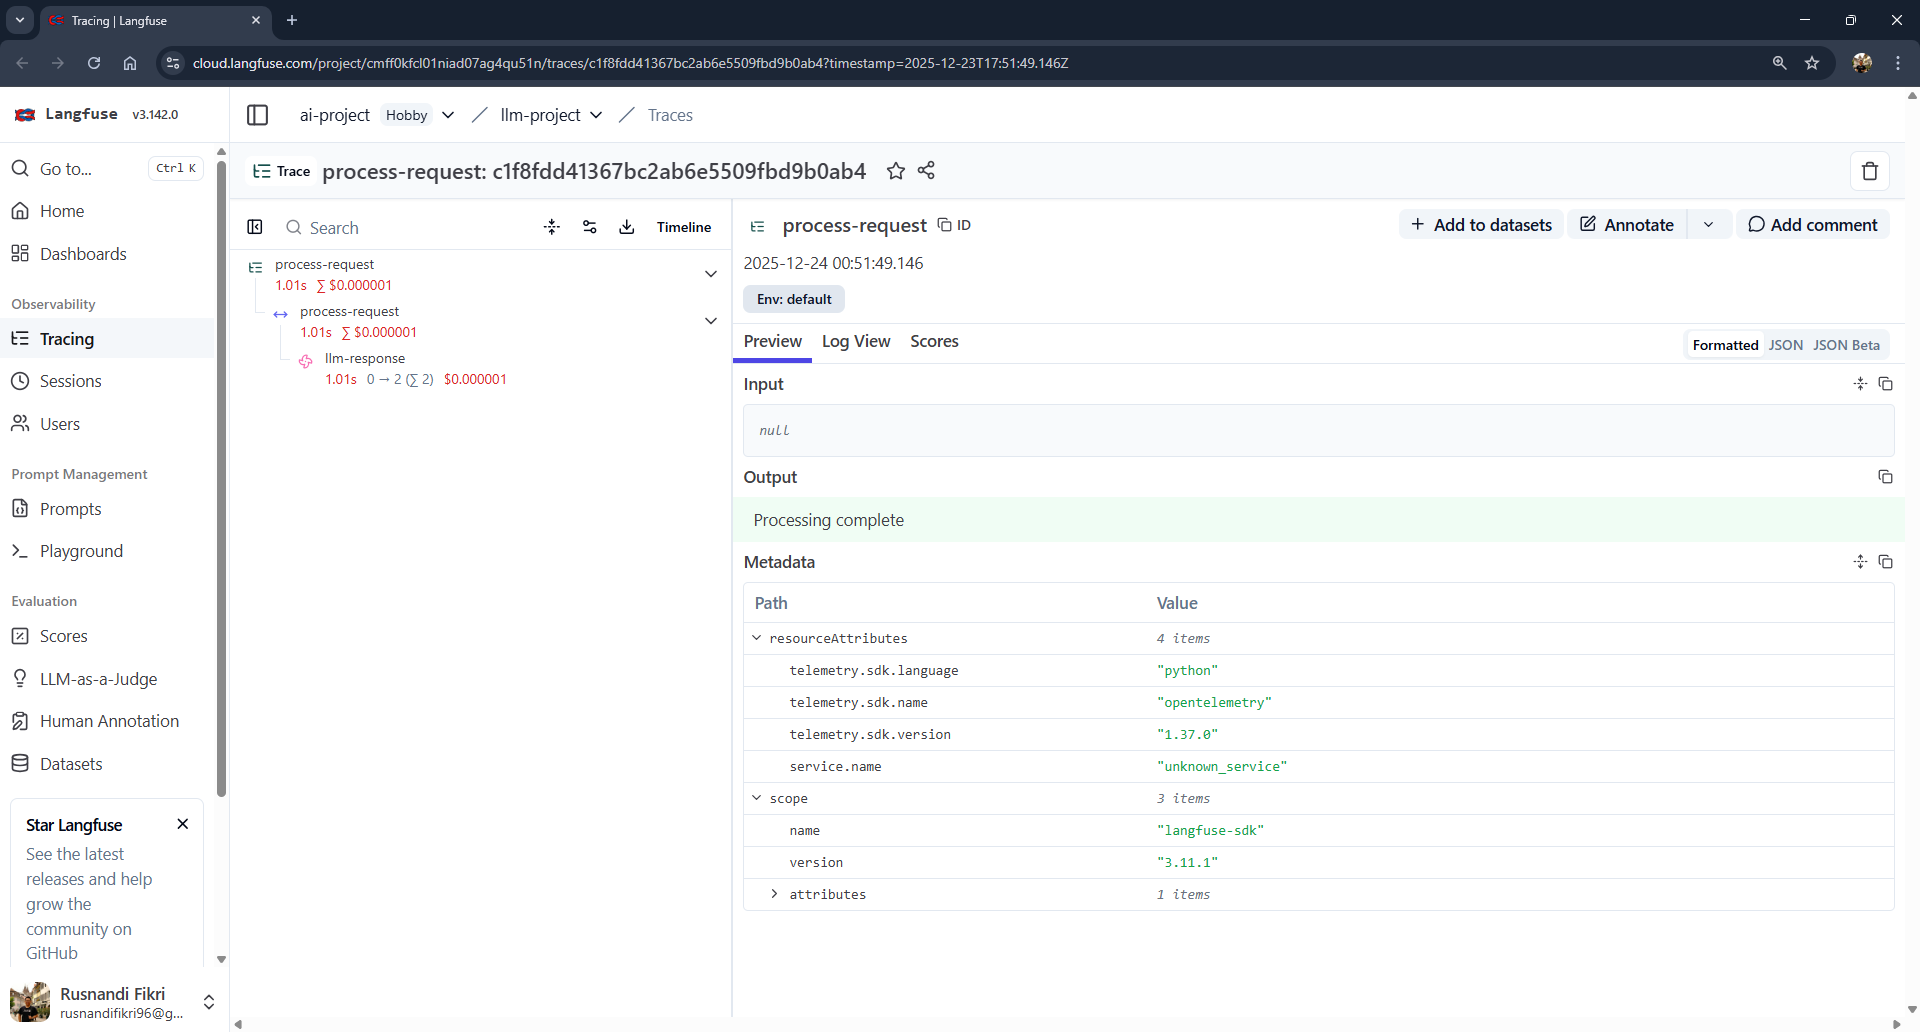

## Prompt Management


Prompt management is a systematic approach to storing, versioning, and retrieving prompts for your LLM application. Instead of hardcoding prompts in your application code, you manage them centrally in Langfuse.



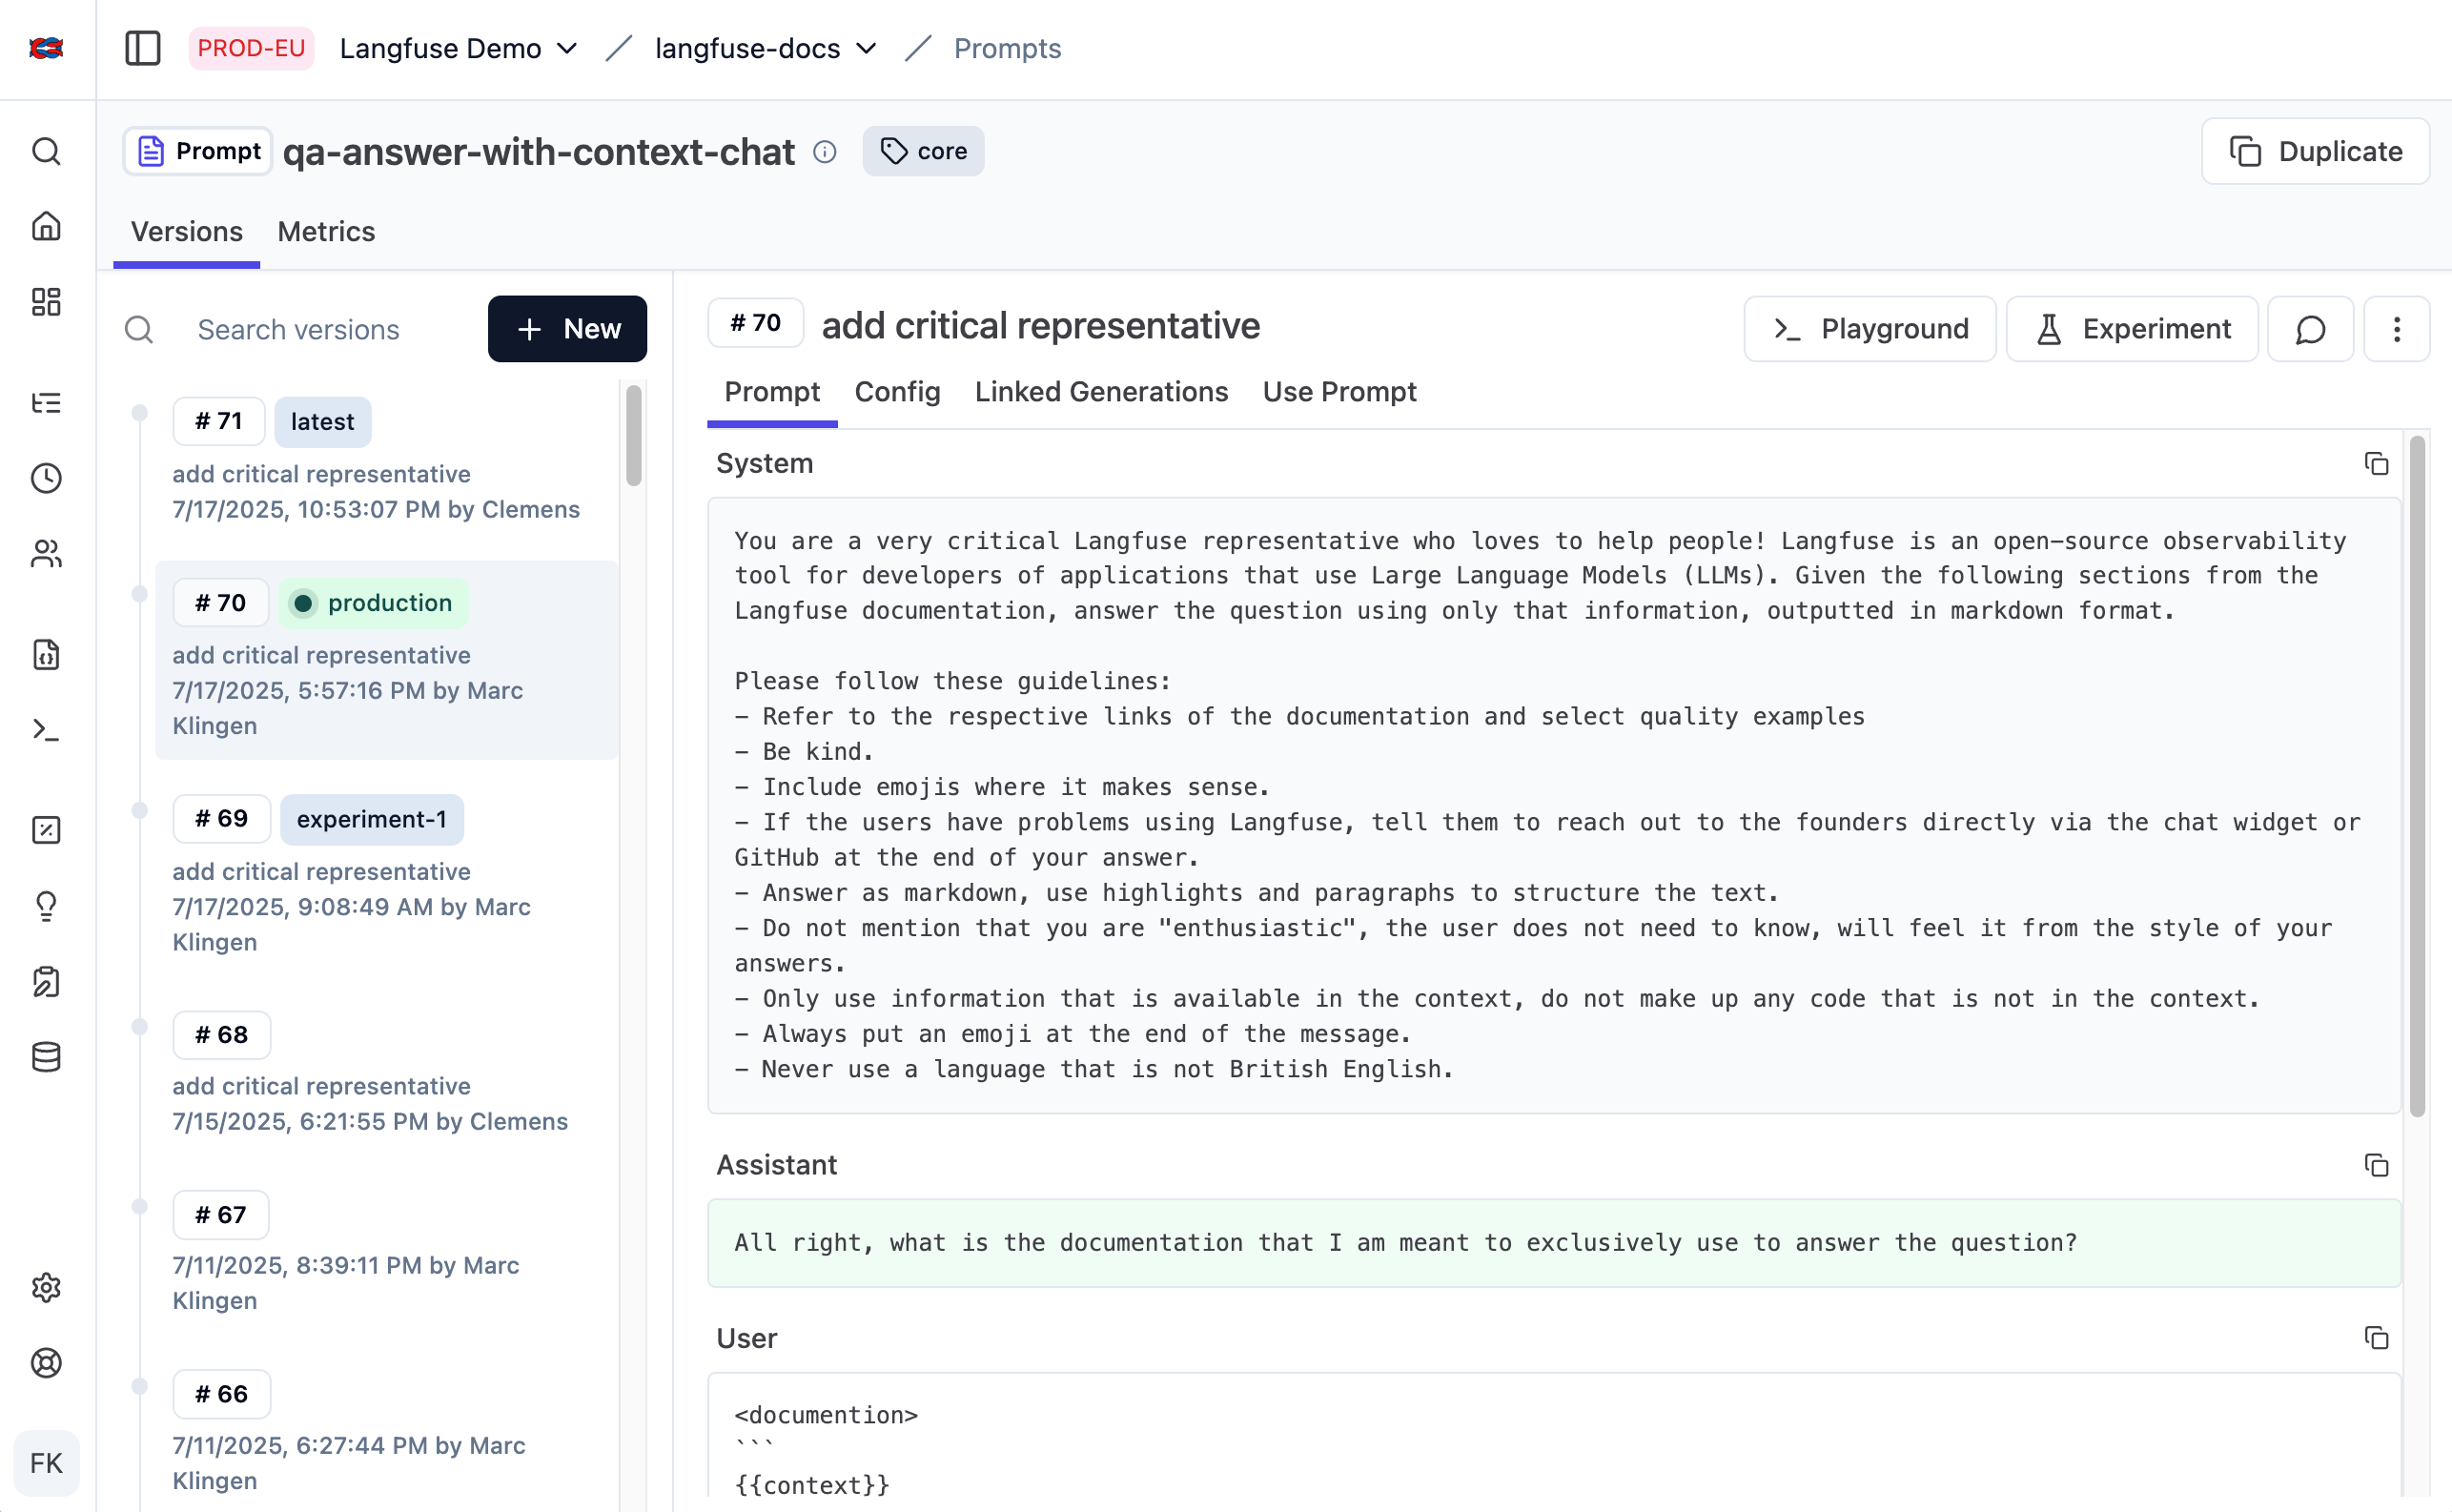

### Create a prompt

In [4]:
langfuse = get_client()

In [5]:
# Create a text prompt
langfuse.create_prompt(
    name="movie-critic",
    type="text",
    prompt="As a {{criticlevel}} movie critic, do you like {{movie}}?",
    labels=["production"]  # optionally, directly promote to production
)

# Create a chat prompt
langfuse.create_prompt(
    name="movie-critic-chat",
    type="chat",
    prompt=[
      { "role": "system", "content": "You are an {{criticlevel}} movie critic" },
      { "role": "user", "content": "Do you like {{movie}}?" },
    ],
    labels=["production"]  # optionally, directly promote to production
)

### Use prompt

In [6]:
# By default, the production version is fetched.
prompt = langfuse.get_prompt("movie-critic")

# Insert variables into prompt template
compiled_prompt = prompt.compile(criticlevel="expert", movie="Dune 2")
# -> "As an expert movie critic, do you like Dune 2?"

In [7]:
compiled_prompt

'As a expert movie critic, do you like Dune 2?'

In [8]:
# By default, the production version of a chat prompt is fetched.
chat_prompt = langfuse.get_prompt("movie-critic-chat", type="chat") # type arg infers the prompt type (default is 'text')

# Insert variables into chat prompt template
compiled_chat_prompt = chat_prompt.compile(criticlevel="expert", movie="Dune 2")
# -> [{"role": "system", "content": "You are an expert movie critic"}, {"role": "user", "content": "Do you like Dune 2?"}]

In [10]:
compiled_chat_prompt

[{'role': 'system', 'content': 'You are an expert movie critic'},
 {'role': 'user', 'content': 'Do you like Dune 2?'}]

### Updating Prompt Version

In [11]:
from langfuse import Langfuse

In [12]:
langfuse = Langfuse()
langfuse.update_prompt(
    name="movie-critic",
    version=1,
    new_labels=["john", "doe"], # assign these labels to the prompt version
)

Prompt_Text(type='text', prompt='As a {{criticlevel}} movie critic, do you like {{movie}}?', name='movie-critic', version=1, config={}, labels=['john', 'doe'], tags=[], commit_message=None, resolution_graph=None, id='56a0e3ff-d11b-4c1a-b2fb-a89d0133fe14', createdAt='2025-12-27T18:21:37.451Z', updatedAt='2026-04-21T14:18:43.310Z', projectId='cmff0kfcl01niad07ag4qu51n', createdBy='API', isActive=None)

In [13]:
from langfuse import get_client

# Initialize Langfuse client
langfuse = get_client()

In [14]:
# Get specific version
prompt = langfuse.get_prompt("movie-critic", version=1)
prompt.compile(criticlevel="expert", movie="Dune 2")

'As a expert movie critic, do you like Dune 2?'

In [17]:
# Get latest prompt version. The 'latest' label is automatically maintained by Langfuse.
latest_prompt = langfuse.get_prompt("movie-critic", label="latest")
latest_prompt.compile(criticlevel="expert", movie="Dune 2")

'As a expert movie critic, do you like Dune 2?'

### Adjust Label on Prompt

In [16]:
# Get specific label
langfuse = get_client()
langfuse.create_prompt(
    name="movie-critic",
    type="text",
    prompt="As a {{criticlevel}} movie critic, do you like {{movie}}?",
    labels=["staging"],  # add the label "staging" to the prompt version
)

In [18]:
# Get specific label
prompt = langfuse.get_prompt("movie-critic", label="staging")

In [19]:
prompt.compile(criticlevel="expert", movie="Dune 2")

'As a expert movie critic, do you like Dune 2?'